# Estructurando un Proyecto de DS

El análisis de datos en el mundo de las criptomonedas es una tarea crucial para entender su comportamiento y predecir su valor futuro. Este estudio utiliza un dataset de 1000 filas con información sobre el Bitcoin, incluyendo las columnas 'timestamp', 'close', 'high', 'low', 'open' y 'volume'. Con este conjunto de datos, se desarrolló un modelo de regresión lineal para predecir el precio de cierre del Bitcoin.

Además de estas columnas, se pretende agregar datos de Twitter para cada fila, incluyendo menciones de influencers relevantes en el mundo de las criptomonedas, como Elon Musk. La idea es que estas menciones puedan tener un impacto significativo en el precio del Bitcoin y, por lo tanto, ser una variable importante a tener en cuenta en la predicción del modelo.

Este estudio es un primer paso hacia una comprensión más profunda de cómo las influencias externas, como las menciones en las redes sociales, pueden afectar el precio de las criptomonedas. Con el tiempo, se espera que este enfoque permita a los inversores y analistas de datos tomar decisiones más informadas sobre el mercado de criptomonedas.

## Preguntas Relevantes
- ¿los comentarios de twitter influyen en el precio del bitcoin?
- ¿Que tan fino se puede manipular el mercado?
- ¿Se puede predecir una suba o baja inminente del precio?

In [60]:
import json
import requests
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

import numpy as np

In [61]:
pair = "btcusd"
parametros = {
    "step":60,
    "limit":1000
}

In [62]:
dataset = requests.get(f"https://www.bitstamp.net/api/v2/ohlc/{pair}/", params = parametros)
dsTemp = dataset.json()["data"]["ohlc"]

In [63]:
df = pd.DataFrame(dsTemp)

In [64]:
df['timestamp'] = pd.to_numeric(df['timestamp'].astype(np.int64))
df['close'] = pd.to_numeric(df['close'].astype(np.int64))
df['high'] = pd.to_numeric(df['high'])
df['low'] = pd.to_numeric(df['low'])
df['volume'] = pd.to_numeric(df['volume'])
df['open'] = pd.to_numeric(df['open'])

df['fecha'] = pd.to_datetime(df['timestamp'], unit='s').dt.date


In [65]:
df.set_index("timestamp")

,close,high,low,open,volume,fecha
timestamp,,,,,,
1676958900,24950,24950,24950,24950,0.002500,2023-02-21
1676958960,24952,24952,24944,24944,3.651477,2023-02-21
1676959020,24952,24953,24949,24950,0.304867,2023-02-21
1676959080,24966,24966,24957,24957,0.182621,2023-02-21
1676959140,24953,24967,24953,24965,0.233102,2023-02-21
...,...,...,...,...,...,...
1677018600,24295,24302,24283,24301,0.028586,2023-02-21
1677018660,24308,24311,24298,24298,0.023560,2023-02-21
1677018720,24296,24302,24295,24301,0.028190,2023-02-21


# Estado del Precio

<AxesSubplot:xlabel='timestamp', ylabel='close'>

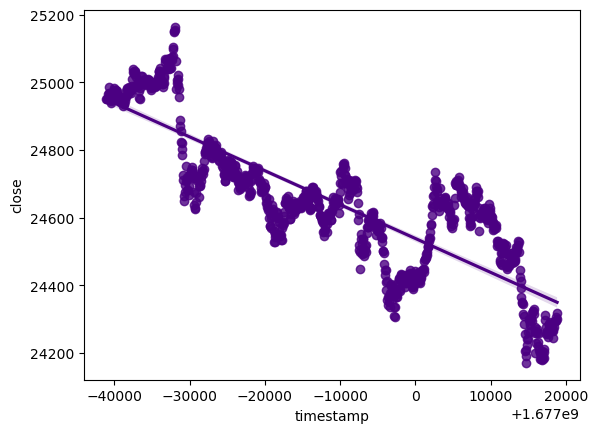

In [66]:
sns.regplot(x="timestamp", y="close", data=df, color="indigo")

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   close      1000 non-null   int64  
 1   high       1000 non-null   int64  
 2   low        1000 non-null   int64  
 3   open       1000 non-null   int64  
 4   timestamp  1000 non-null   int64  
 5   volume     1000 non-null   float64
 6   fecha      1000 non-null   object 
dtypes: float64(1), int64(5), object(1)
memory usage: 54.8+ KB


# Primare implementacion de modelo de regresion lineal

In [68]:
X = df[['high', 'low', 'open', 'timestamp', 'volume']]
y = df['close']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.8, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [69]:
y_pred = model.predict(X_test)

In [70]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

In [71]:
print('RMSE:', rmse)

RMSE: 7.352192507316288


In [72]:
from sklearn.metrics import r2_score

y_train_pred = model.predict(X_train)
r2 = r2_score(y_train, y_train_pred)

print('Aproximacion:', r2)

Aproximacion: 0.998869644756925


In [73]:
n_future = 50
future_timestamps = np.arange(timestamps[-1] + 1, timestamps[-1] + n_future + 1)
future_data = pd.DataFrame({'timestamp': future_timestamps, 'open': np.zeros(n_future), 'high': np.zeros(n_future), 'low': np.zeros(n_future), 'close': np.zeros(n_future), 'volume': np.zeros(n_future), 'fecha': pd.date_range(fecha[-1], periods=n_future+1, freq='D')[1:]})


NameError: name 'timestamps' is not defined